# Model `tran_cena_brutto` (cena transakcyjna lokalu mieszkalnego)

Źródło: `lublin_data_epsg2180.gml` (bez osobnego pliku dzielnic).  
Kohort: `lok_funkcja == "mieszkalna"`, rok `dok_data` w {2025, 2026}.  
Z modelu wyłączone potencjalnie „wyciekające” kolumny cen (`lok_cena_brutto`, `nier_cena_brutto`, VAT).

**Ulepszenia:** obcięcie outlierów ceny (`PRICE_QUANTILE_CLIP`), cechy czasu (`dok_miesiac`, `dok_kwartał`, `dok_dzien_roku`), bucket piętra (`lok_pietro_bucket`), porównanie **4 modeli** × **2 podziały** (losowy 80/20 vs. ostatnie 20% wg daty).

**Duży plik (~90k wierszy):** `MAX_ROWS` + pyogrio (`rows=slice`) — ustaw `None` dla pełnego zbioru.

In [15]:
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore", category=UserWarning)

In [16]:
GML_PATH = "lublin_data_epsg2180.gml"

# Ograniczenie liczby wczytywanych wierszy (duży plik ~90k). Ustaw None, żeby wczytać całość.
MAX_ROWS: int | None = None


def load_lublin_gdf(path: str, max_rows: int | None) -> gpd.GeoDataFrame:
    """Wczytuje GML; przy max_rows używa silnika pyogrio i slice wierszy (nie cały plik ~90k)."""
    kwargs: dict = {"encoding": "UTF-8"}
    if max_rows is not None:
        kwargs["engine"] = "pyogrio"
        kwargs["rows"] = slice(0, max_rows)
    try:
        return gpd.read_file(path, **kwargs)
    except Exception as e:
        if max_rows is not None:
            print(
                "Uwaga: pyogrio/rows niedostępne (",
                type(e).__name__,
                ") — wczytywany jest cały plik. Zainstaluj pyogrio: pip install pyogrio",
            )
            return gpd.read_file(path, encoding="UTF-8")
        raise


gdf = load_lublin_gdf(GML_PATH, MAX_ROWS)
print("Wczytano wierszy:", len(gdf), "| MAX_ROWS:", MAX_ROWS)

Wczytano wierszy: 96666 | MAX_ROWS: None


In [17]:
gdf["dok_data"] = pd.to_datetime(gdf["dok_data"], errors="coerce", utc=True)
mask_cohort = (gdf["lok_funkcja"] == "mieszkalna") & (
    gdf["dok_data"].dt.year.isin([2025, 2026])
)
df = gdf.loc[mask_cohort].copy()

print("Po filtrze (mieszkalna, 2025–2026):", len(df), "wierszy")
if len(df):
    print(df["dok_data"].dt.year.value_counts(dropna=False).sort_index())
    y_raw = pd.to_numeric(df["tran_cena_brutto"], errors="coerce")
    print(y_raw.describe())

Po filtrze (mieszkalna, 2025–2026): 4249 wierszy
dok_data
2025    4241
2026       8
Name: count, dtype: int64
count    4.249000e+03
mean     5.732037e+05
std      2.985468e+05
min      0.000000e+00
25%      4.000000e+05
50%      5.150000e+05
75%      6.598200e+05
max      3.578800e+06
Name: tran_cena_brutto, dtype: float64


In [18]:
# Opcje przygotowania danych
PRICE_QUANTILE_CLIP: tuple[float, float] | None = (0.01, 0.98)  # None = bez obcinania outlierów ceny

LEAKAGE_COLS = {
    "lok_cena_brutto",
    "nier_cena_brutto",
    "tran_vat",
    "lok_vat",
    "nier_vat",
}

NUMERIC_CANDIDATES = [
    "lok_pow_uzyt",
    "lok_pow_przyn",
    "lok_liczba_izb",
    "lok_nr_kond",
    "nier_pow_gruntu",
]
CATEGORICAL_CANDIDATES = [
    "dzielnica",
    "tran_rodzaj_trans",
    "tran_rodzaj_rynku",
    "tran_sprzedajacy",
    "tran_kupujacy",
    "nier_rodzaj",
    "nier_prawo",
    "teryt",
]


def coerce_numeric(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def floor_bucket_cat(k: pd.Series) -> pd.Series:
    """Grupy kondygnacji dla modeli drzewiastych."""
    out = pd.Series("unknown", index=k.index, dtype="string")
    v = pd.to_numeric(k, errors="coerce")
    m = v.notna()
    out.loc[m & (v <= 0)] = "parter_lub_zero"
    out.loc[m & (v > 0) & (v <= 3)] = "pietro_1_3"
    out.loc[m & (v > 3) & (v <= 10)] = "pietro_4_10"
    out.loc[m & (v > 10)] = "pietro_11plus"
    return out


def add_xy_from_geometry(frame: gpd.GeoDataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=frame.index)
    if hasattr(frame, "geometry") and frame.geometry.notna().any():
        cx = frame.geometry.x
        cy = frame.geometry.y
        out["coord_x"] = cx
        out["coord_y"] = cy
    return out


def prepare_features(df_in: gpd.GeoDataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    num_cols = [c for c in NUMERIC_CANDIDATES if c in df_in.columns and c not in LEAKAGE_COLS]
    cat_cols = [c for c in CATEGORICAL_CANDIDATES if c in df_in.columns and c not in LEAKAGE_COLS]

    X = pd.DataFrame(index=df_in.index)
    for c in num_cols:
        X[c] = coerce_numeric(df_in[c])

    xy = add_xy_from_geometry(df_in)
    for c in xy.columns:
        X[c] = xy[c]

    # Czas (sezonowość / trend w kohortcie)
    if "dok_data" in df_in.columns:
        dt = pd.to_datetime(df_in["dok_data"], errors="coerce", utc=True)
        m = dt.notna()
        X["dok_miesiac"] = "unknown"
        X.loc[m, "dok_miesiac"] = dt.dt.strftime("%Y-%m")[m]
        X["dok_kwartał"] = "unknown"
        X.loc[m, "dok_kwartał"] = (
            dt.dt.year.astype(int).astype(str)[m] + "Q" + dt.dt.quarter.astype(int).astype(str)[m]
        )
        X["dok_dzien_roku"] = np.nan
        X.loc[m, "dok_dzien_roku"] = dt.dt.dayofyear[m].astype(float)

    if "lok_nr_kond" in df_in.columns:
        X["lok_pietro_bucket"] = floor_bucket_cat(coerce_numeric(df_in["lok_nr_kond"]))

    engineered_cat = [c for c in ("dok_miesiac", "dok_kwartał", "lok_pietro_bucket") if c in X.columns]
    for c in engineered_cat:
        if c not in cat_cols:
            cat_cols = cat_cols + [c]

    for c in cat_cols:
        if c in engineered_cat:
            X[c] = X[c].astype("string").fillna("unknown").replace({"<NA>": "unknown"})
        else:
            v = df_in[c].astype("string")
            X[c] = v.fillna("unknown").replace({"<NA>": "unknown"})

    num_features = [c for c in X.columns if c not in cat_cols]
    cat_features = list(cat_cols)
    return X, num_features, cat_features


y = pd.to_numeric(df["tran_cena_brutto"], errors="coerce")
valid = y.notna() & (y > 0)
df_m = df.loc[valid].copy()
y = y.loc[valid]

if PRICE_QUANTILE_CLIP is not None:
    lo, hi = PRICE_QUANTILE_CLIP
    y_lo, y_hi = y.quantile(lo), y.quantile(hi)
    mask_q = (y >= y_lo) & (y <= y_hi)
    n_drop = int((~mask_q).sum())
    df_m = df_m.loc[mask_q].copy()
    y = y.loc[mask_q]
    print(f"Po obcięciu cen do kwantyli [{lo}, {hi}]: usunięto {n_drop} wierszy (granice {y_lo:,.0f} … {y_hi:,.0f} PLN)")

X, num_features, cat_features = prepare_features(df_m)
print("Cechy numeryczne:", num_features)
print("Cechy kategoryczne:", cat_features)
print("X shape:", X.shape)

Po obcięciu cen do kwantyli [0.01, 0.98]: usunięto 127 wierszy (granice 170,470 … 1,450,552 PLN)
Cechy numeryczne: ['lok_pow_uzyt', 'lok_pow_przyn', 'lok_liczba_izb', 'lok_nr_kond', 'nier_pow_gruntu', 'coord_x', 'coord_y', 'dok_dzien_roku']
Cechy kategoryczne: ['dzielnica', 'tran_rodzaj_trans', 'tran_rodzaj_rynku', 'tran_sprzedajacy', 'tran_kupujacy', 'nier_rodzaj', 'nier_prawo', 'teryt', 'dok_miesiac', 'dok_kwartał', 'lok_pietro_bucket']
X shape: (4121, 19)


In [19]:
def rmse_pln(y_true, y_pred):
    try:
        from sklearn.metrics import root_mean_squared_error

        return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape_pct(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    m = yt > 0
    if not m.any():
        return float("nan")
    return float(np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100)


def make_preprocess(num_feats: list[str], cat_feats: list[str]) -> ColumnTransformer:
    numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_transformer = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]
    )
    transformers = []
    if num_feats:
        transformers.append(("num", numeric_transformer, num_feats))
    if cat_feats:
        transformers.append(("cat", categorical_transformer, cat_feats))
    if not transformers:
        raise SystemExit("Brak cech numerycznych i kategorycznych.")
    return ColumnTransformer(transformers=transformers, remainder="drop")


def build_pipeline(estimator, num_feats: list[str], cat_feats: list[str]):
    prep = make_preprocess(num_feats, cat_feats)
    base = Pipeline([("prep", prep), ("model", estimator)])
    return TransformedTargetRegressor(
        regressor=base, func=np.log1p, inverse_func=np.expm1
    )


def split_time_last_fraction(X, y, dates: pd.Series, test_size: float = 0.2):
    """Ostatnie test_size części transakcji wg daty dokumentu (symulacja prognozy 'w przód')."""
    d = pd.to_datetime(dates, errors="coerce", utc=True).reindex(X.index)
    idx_sorted = d.sort_values(na_position="first").index
    n_test = max(1, int(len(idx_sorted) * test_size))
    train_idx = idx_sorted[:-n_test]
    test_idx = idx_sorted[-n_test:]
    return X.loc[train_idx], X.loc[test_idx], y.loc[train_idx], y.loc[test_idx]


if len(X) < 20:
    raise SystemExit(
        "Za mało próbek — ustaw MAX_ROWS=None lub poszerz okno dat; "
        "pierwsze N wierszy pliku może nie zawierać kohorty 2025–2026."
    )

dates_series = pd.to_datetime(df_m["dok_data"], errors="coerce", utc=True).reindex(X.index)

ESTIMATORS: dict[str, object] = {
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_depth=10,
        learning_rate=0.06,
        max_iter=350,
        min_samples_leaf=12,
        l2_regularization=0.08,
        random_state=42,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=250,
        max_depth=22,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=24,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        max_depth=5,
        n_estimators=220,
        learning_rate=0.06,
        min_samples_leaf=8,
        random_state=42,
    ),
}

SPLITS = {
    "random_80_20": lambda: train_test_split(
        X, y, test_size=0.2, random_state=42
    ),
    "time_last_20pct": lambda: split_time_last_fraction(
        X, y, dates_series, test_size=0.2
    ),
}

results_rows = []
fitted: dict = {}
test_sets: dict = {}

for split_name, split_fn in SPLITS.items():
    X_tr, X_te, y_tr, y_te = split_fn()
    test_sets[split_name] = (X_te, y_te)
    for model_name, est in ESTIMATORS.items():
        pipe = build_pipeline(est, num_features, cat_features)
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)
        results_rows.append(
            {
                "split": split_name,
                "model": model_name,
                "mae_pln": mean_absolute_error(y_te, pred),
                "rmse_pln": rmse_pln(y_te, pred),
                "r2_pln": r2_score(y_te, pred),
                "r2_log": r2_score(np.log1p(y_te), np.log1p(pred)),
                "mape_pct": mape_pct(y_te, pred),
                "n_train": len(X_tr),
                "n_test": len(X_te),
            }
        )
        fitted[(split_name, model_name)] = pipe

results_df = pd.DataFrame(results_rows)
show = results_df[
    ["split", "model", "mae_pln", "rmse_pln", "r2_pln", "r2_log", "mape_pct"]
].sort_values(["split", "mae_pln"])
print(show.round(3).to_string(index=False))

best = results_df.sort_values("mae_pln").iloc[0]
print(
    f"\nNajlepsze MAE: {best['model']} | split: {best['split']} | "
    f"MAE={best['mae_pln']:,.0f} PLN | R²={best['r2_pln']:.3f}"
)
best_key = (best["split"], best["model"])
model = fitted[best_key]
X_test_eval, y_test_eval = test_sets[best["split"]]
pred_eval = model.predict(X_test_eval)

          split                model   mae_pln   rmse_pln  r2_pln  r2_log  mape_pct
   random_80_20           ExtraTrees 73629.401 128585.376   0.612   0.674    12.931
   random_80_20 HistGradientBoosting 74120.183 127472.225   0.619   0.676    13.108
   random_80_20     GradientBoosting 75960.019 130533.048   0.600   0.668    13.297
   random_80_20         RandomForest 76272.038 131955.052   0.591   0.654    13.490
time_last_20pct           ExtraTrees 71308.162 117470.185   0.639   0.671    13.326
time_last_20pct HistGradientBoosting 72816.373 122885.269   0.605   0.631    13.576
time_last_20pct     GradientBoosting 73239.526 122411.895   0.608   0.648    13.556
time_last_20pct         RandomForest 75304.855 124814.262   0.593   0.627    14.108

Najlepsze MAE: ExtraTrees | split: time_last_20pct | MAE=71,308 PLN | R²=0.639


In [20]:
r = permutation_importance(
    model, X_test_eval, y_test_eval, n_repeats=10, random_state=42, n_jobs=-1
)
feat_names = num_features + cat_features
imp = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False)
print("Permutation importance (średnia):")
print(imp.to_string())

Permutation importance (średnia):
lok_pow_uzyt         8.326422e-01
lok_liczba_izb       8.780165e-02
nier_prawo           7.745081e-02
tran_sprzedajacy     3.974626e-02
teryt                3.922156e-02
coord_x              3.487935e-02
coord_y              3.178883e-02
tran_kupujacy        1.330380e-02
nier_pow_gruntu      1.245462e-02
tran_rodzaj_rynku    4.093918e-03
lok_nr_kond          2.235847e-03
nier_rodzaj          1.706886e-03
dok_dzien_roku       1.580330e-03
lok_pow_przyn        8.576555e-04
dzielnica            5.383224e-04
tran_rodzaj_trans    1.136403e-04
dok_miesiac          3.108624e-16
dok_kwartał          1.554312e-16
lok_pietro_bucket   -3.986714e-04


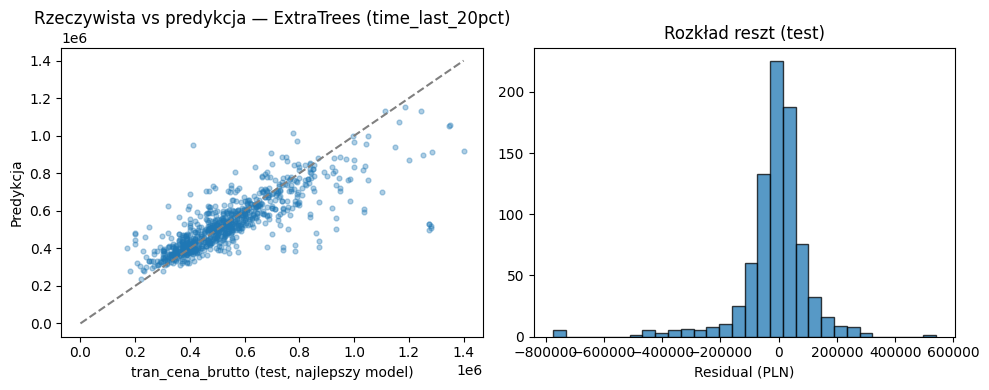

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(y_test_eval, pred_eval, alpha=0.35, s=12)
mx = float(max(y_test_eval.max(), pred_eval.max()))
ax[0].plot([0, mx], [0, mx], color="gray", linestyle="--")
ax[0].set_xlabel("tran_cena_brutto (test, najlepszy model)")
ax[0].set_ylabel("Predykcja")
ax[0].set_title(f"Rzeczywista vs predykcja — {best['model']} ({best['split']})")

res = pred_eval - y_test_eval
ax[1].hist(res, bins=30, edgecolor="black", alpha=0.75)
ax[1].set_xlabel("Residual (PLN)")
ax[1].set_title("Rozkład reszt (test)")
plt.tight_layout()
plt.show()

## Podsumowanie

- **Kohort**: mieszkalna, 2025–2026; cel `tran_cena_brutto` (> 0); opcjonalnie **kwantyle cen** (`PRICE_QUANTILE_CLIP`) odsiewają skrajne transakcje.
- **Wyciek**: bez `lok_cena_brutto`, `nier_cena_brutto`, VAT.
- **Cechy**: powierzchnie, współrzędne, dzielnica, transakcja, **kalendarz** i **bucket piętra**.
- **Modele**: HistGradientBoosting, RandomForest, ExtraTrees, GradientBoosting — tabela metryk dla **splitu losowego** i **czasowego** (ostatnie 20% wg `dok_data`).
- **Trening**: `log1p` celu; wykresy i permutation importance dla **najlepszego** modelu wg MAE na teście.